# Real-asteroid evaluation -- segmentation model + focal cutout CNN vs LSST 5σ stack

Mirror of `Evaluation.ipynb` on the real fast-mover test set. Pure analysis of the
pre-built per-sighting and per-panel catalogs in `Evaluation/catalogs/` -- no NN
inference here.

The catalogs are produced ahead of time by
`python -m ADCNN.inference.build_real_eval_catalog`, which joins the detection catalog
(written by `ADCNN.inference.stream_real_inference`, the Butler-streaming runner) to
the real-asteroid truth and the LSST forced-photometry baseline.

Differences from the simulated eval (forced by the data):

- The LSST 5σ stack baseline (`stack_detected`) and forced-photometry SNR
  (`lsst_psf_snr`) are carried over from the LSST DRP forced-photometry catalog -- they
  don't depend on which detector model produced `nn_detected`.
- FP/panel is averaged over the streamed fast-mover panels (the simulated eval reserves
  150 empty panels for FP).
- No threshold ladder (real data has only one stack-sigma variant).


In [1]:
%matplotlib inline
from pathlib import Path
import sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'ADCNN').is_dir())
sys.path.insert(0, str(REPO))
import ADCNN.evaluation as evals

# Per-sighting + per-panel catalogs (pre-built by ADCNN.inference.build_real_eval_catalog).
B = REPO / 'Evaluation/catalogs'
ps  = pd.read_csv(B/'test_real_per_sighting.csv')   # truth + nn_detected + stack_detected
fpp = pd.read_csv(B/'test_real_per_panel_fp.csv')   # per-panel detection counts (TP + FP)

ps['nn_detected']    = ps['nn_detected'].astype(bool)
ps['stack_detected'] = ps['stack_detected'].astype(bool)
cat = ps.dropna(subset=['lsst_psf_snr']).copy()
cat['SNR']             = cat['lsst_psf_snr']
cat['stack_detection'] = cat['stack_detected']

n_panels = int(fpp['image_id'].nunique())
nn_fp    = int(fpp['nn_fp'].sum())
# Stack FP rate is measured separately on empty real panels (see the simulated eval); the
# real-asteroid catalog itself doesn't carry empty-panel rows.
stack_fp = 0

print(f"sightings: {len(ps)}   unique objects: {ps.ObjID.nunique()}   "
      f"(forced-phot subset for SNR plots: {len(cat)})")
print(f"  stack: {int(ps.stack_detected.sum())}   NN: {int(ps.nn_detected.sum())}   "
      f"combined: {int((ps.stack_detected|ps.nn_detected).sum())}")
print(f"FP/panel (NN): {nn_fp/max(n_panels,1):.1f}   ({nn_fp} total over {n_panels} panels)")


sightings: 2230   unique objects: 288   (forced-phot subset for SNR plots: 2229)
  stack: 1313   NN: 1169   combined: 1385
FP/panel (NN): 110.6   (246732 total over 2230 panels)


## LSST stack (5σ)

Per-sighting — LSST stack 5σ  (stack FP not measured by streaming pipeline)
F1 Score: 0.7412, F2 Score: 0.6416
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>                   0
Actual Positive                 917                1313



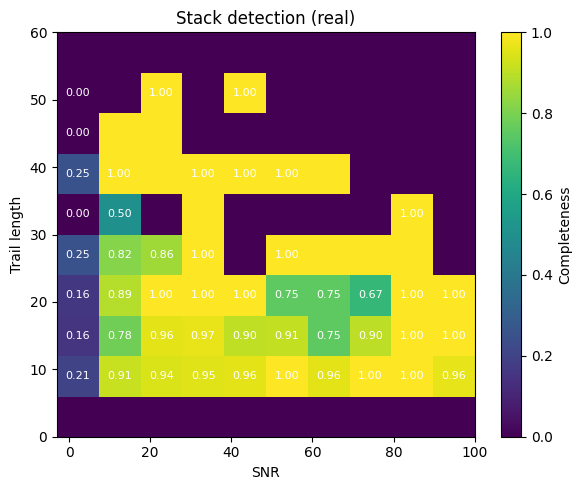

In [2]:
def _cm(col, fp):
    tp=int(ps[col].sum()); fn=int((~ps[col].astype(bool)).sum())
    return {"TP":tp,"FP":fp,"FN":fn,"TN":pd.NA}

evals.print_confusion_matrix(_cm('stack_detected', stack_fp),
    title="Per-sighting — LSST stack 5σ  (stack FP not measured by streaming pipeline)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['stack_detection'].values,
    title="Stack detection (real)")
plt.show()

## segmentation model + focal cutout CNN


Per-sighting — segmentation model + focal cutout CNN  (FP = NN dets matching no truth over 2230 panels)
F1 Score: 0.0093, F2 Score: 0.0228
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              246732
Actual Positive                1061                1169

Per-sighting — combined (stack OR NN)
F1 Score: 0.0111, F2 Score: 0.0269
                 Predicted Negative  Predicted Positive
Actual Negative                <NA>              246732
Actual Positive                 845                1385



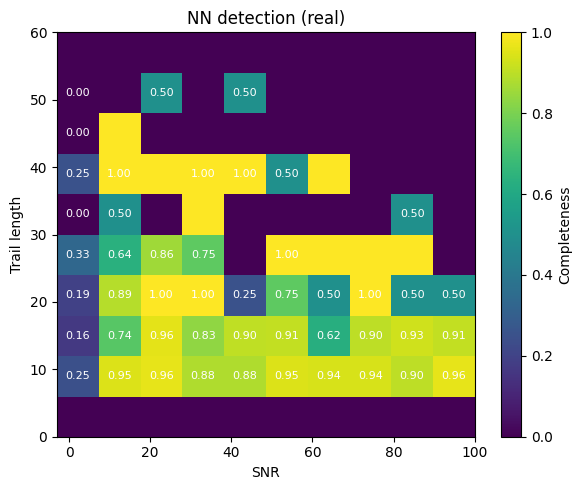

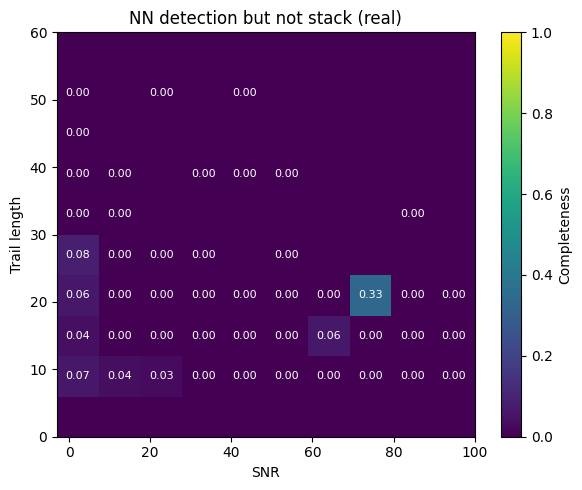

In [3]:
evals.print_confusion_matrix(_cm('nn_detected', nn_fp),
    title="Per-sighting — segmentation model + focal cutout CNN  (FP = NN dets matching no truth over 2230 panels)")
comb = (ps.stack_detected.astype(bool) | ps.nn_detected.astype(bool))
evals.print_confusion_matrix({"TP":int(comb.sum()),"FP":stack_fp+nn_fp,
    "FN":int((~comb).sum()),"TN":pd.NA},
    title="Per-sighting — combined (stack OR NN)")
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60), detected=cat['nn_detected'].values,
    title="NN detection (real)")
plt.show()
evals.plot_completeness_2d(cat, snr_bins=10, trail_bins=10, snr_range=(-3,100),
    trail_range=(0,60),
    detected=(~cat['stack_detection'].values & cat['nn_detected'].values),
    title="NN detection but not stack (real)")
plt.show()

## Second-stage value (stack-missed only) + false positives

In [4]:
miss = ps[~ps.stack_detected.astype(bool)]
print(f"stack-missed sightings: {len(miss)} / {len(ps)}")
print(f"  NN recovers {int(miss.nn_detected.sum())} "
      f"({100*miss.nn_detected.mean():.1f}%)   <-- pure 2nd-stage gain")
g = ps.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detected','any'))
print(f"objects: stack {int(g.st.sum())}/{len(g)}   "
      f"combined {int((g.st|g.nn).sum())}/{len(g)}   "
      f"(NN-only NEW objects: {int((g.nn & ~g.st).sum())})")
print(f"\nFP measured over all {n_panels} streamed fast-mover panels:")
print(f"  NN: {nn_fp} total  ({nn_fp/max(n_panels,1):.1f}/panel)")
print("  stack diaSrc: not measured by the streaming pipeline (no empty-panel pool)")


stack-missed sightings: 917 / 2230
  NN recovers 72 (7.9%)   <-- pure 2nd-stage gain
objects: stack 189/288   combined 195/288   (NN-only NEW objects: 6)

FP measured over all 2230 streamed fast-mover panels:
  NN: 246732 total  (110.6/panel)
  stack diaSrc: not measured by the streaming pipeline (no empty-panel pool)


# Completeness histograms

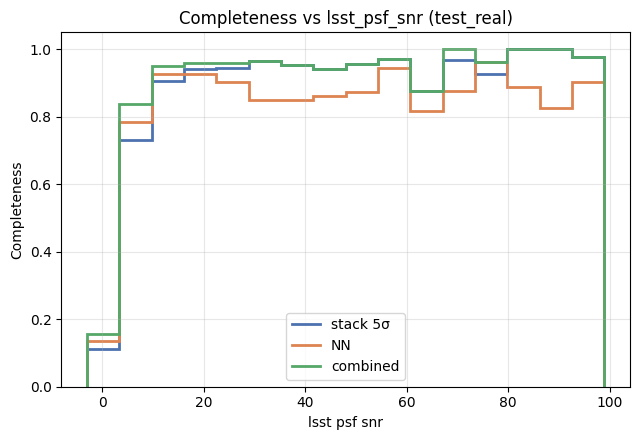

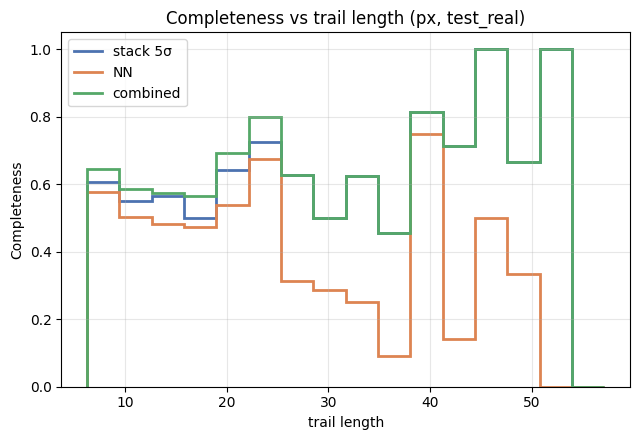

In [5]:
def plot_completeness(cat, field, bins=16, xlim=None, title=None, log_x=False):
    """density-mode completeness (detected/all per bin); curves: stack / NN / combined."""
    v = cat[field].to_numpy().astype(float); v = v[np.isfinite(v)]
    if xlim is not None: v = v[(v>=xlim[0]) & (v<=xlim[1])]
    edges = np.histogram_bin_edges(v, bins=bins)
    fig, ax = plt.subplots(figsize=(6.5,4.5))
    all_i = np.histogram(cat[field], bins=edges)[0].astype(float)
    for label, mask, color in [
        ('stack 5σ',     cat.stack_detection,                       '#4c72b0'),
        ('NN', cat.nn_detected,                           '#dd8452'),
        ('combined',     cat.stack_detection | cat.nn_detected,     '#55a868')]:
        det_i = np.histogram(cat[cat[field].notna() & mask][field], bins=edges)[0].astype(float)
        ax.stairs(det_i/np.maximum(all_i,1), edges, label=label, color=color, lw=2)
    ax.set_xlabel(field.replace('_',' ')); ax.set_ylabel('Completeness')
    if log_x: ax.set_xscale('symlog', linthresh=3)
    if title: ax.set_title(title)
    ax.grid(True, alpha=0.3); ax.set_ylim(0,1.05); ax.legend(loc='best')
    plt.tight_layout(); return fig, ax

plot_completeness(cat,'lsst_psf_snr',bins=16,xlim=(-3,100),
                  title='Completeness vs lsst_psf_snr (test_real)'); plt.show()
plot_completeness(cat,'trail_length',bins=16,xlim=(0,60),
                  title='Completeness vs trail length (px, test_real)'); plt.show()

# Fair comparison: NN training region only (SNR 2–10, trail 6–60 px)

The full real catalog is selection-biased: every object is a *known* fast mover that some
prior survey was already bright enough to detect, so the forced-photometry SNR distribution
stretches into the thousands. segmentation model, by contrast, was trained **only** on synthetic injections
with **SNR ∈ [2, 10]** and **trail length ∈ [6, 60] px** — it has never seen signal outside
that box, so it cannot be expected to fire there. The plots below restrict the real sample to
exactly that training region, the only regime where a NN-vs-stack comparison is apples-to-apples.
(SNR = LSST forced-photometry `lsst_psf_snr`, defined even for stack-missed sightings.)

in-region sightings: 306   objects: 100
  per-sighting  stack 187/306 (61.1%)   NN 211/306 (69.0%)   combined 222/306
  stack-missed sightings: 119  ->  NN recovers 35 (29.4%)
  per-object    stack 69/100  combined 73/100  (NN-only NEW: 4)


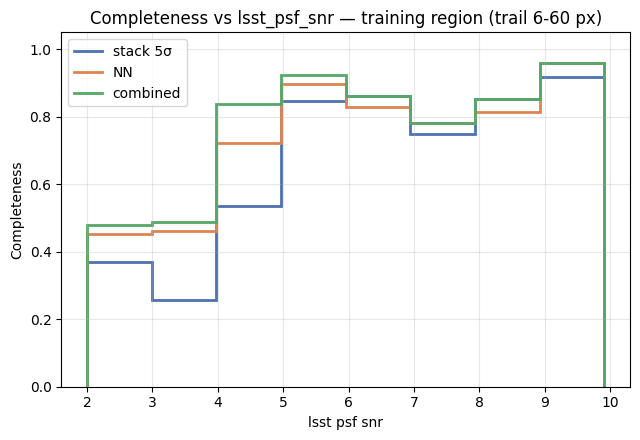

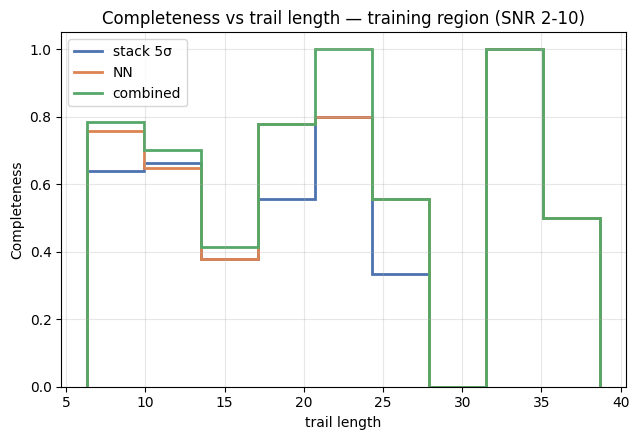

In [6]:
# --- restrict to the segmentation model training box: SNR in [2,10] AND trail in [6,60] px ---
SNR_LO, SNR_HI = 2.0, 10.0
TR_LO, TR_HI   = 6.0, 60.0
reg = cat[(cat.lsst_psf_snr >= SNR_LO) & (cat.lsst_psf_snr <= SNR_HI) &
          (cat.trail_length >= TR_LO) & (cat.trail_length <= TR_HI)].copy()

n_sgt = len(reg)
greg = reg.groupby('ObjID').agg(nn=('nn_detected','any'), st=('stack_detection','any'))
mreg = reg[~reg.stack_detection]
print(f"in-region sightings: {n_sgt}   objects: {len(greg)}")
print(f"  per-sighting  stack {int(reg.stack_detection.sum())}/{n_sgt} "
      f"({100*reg.stack_detection.mean():.1f}%)   "
      f"NN {int(reg.nn_detected.sum())}/{n_sgt} ({100*reg.nn_detected.mean():.1f}%)   "
      f"combined {int((reg.stack_detection|reg.nn_detected).sum())}/{n_sgt}")
print(f"  stack-missed sightings: {len(mreg)}  ->  NN recovers "
      f"{int(mreg.nn_detected.sum())} ({100*mreg.nn_detected.mean() if len(mreg) else 0:.1f}%)")
print(f"  per-object    stack {int(greg.st.sum())}/{len(greg)}  "
      f"combined {int((greg.st|greg.nn).sum())}/{len(greg)}  "
      f"(NN-only NEW: {int((greg.nn & ~greg.st).sum())})")

# completeness vs SNR, finely binned across the 2-10 training window
plot_completeness(reg, 'lsst_psf_snr', bins=8, xlim=(SNR_LO, SNR_HI),
                  title=f'Completeness vs lsst_psf_snr — training region '
                        f'(trail {TR_LO:.0f}-{TR_HI:.0f} px)'); plt.show()
plot_completeness(reg, 'trail_length', bins=9, xlim=(TR_LO, TR_HI),
                  title=f'Completeness vs trail length — training region '
                        f'(SNR {SNR_LO:.0f}-{SNR_HI:.0f})'); plt.show()

## Performance at the adopted pipeline operating point (S ≥ 0.80)

The CNN cut above is the **catalog-generation** threshold (FPP-budget calibrated). The discovery/alert
pipeline consumes this catalog at the **adopted operating point** selected by the formal threshold
protocol (`ADCNN/pipelines/heliolinc/THRESHOLD_PROTOCOL.md`, frozen before the blind test):
`score >= 0.80`, plus `mfsnr >= 5` for the 2-visit alert tier. This section reports the same
catalog metrics re-cut at that operating point (recall by detection-SNR bin: the faint-fast science
bins are SNR 2–5 and 5–10).

In [7]:
# Adopted-operating-point on REAL data -- what is measurable from the prebuilt catalogs:
st = ps['stack_detected'].astype(bool); nn = ps['nn_detected'].astype(bool); comb = st | nn
print(f'per-sighting recall (n={len(ps)} real catalogued-asteroid sightings):')
print(f'  LSST stack 5-sigma : {st.mean():.3f}')
print(f'  seg+CNN NN         : {nn.mean():.3f}   (catalog-default CNN cut)')
print(f'  combined           : {comb.mean():.3f}')
print()
print('NOTE -- score-resolved recall at the adopted pipeline operating point (S>=0.80, and the alert-tier')
print('mfsnr>=5 feed; ADCNN/pipelines/heliolinc/THRESHOLD_PROTOCOL.md) is NOT computable from these')
print('prebuilt catalogs: per-sighting rows do not retain the matched detection score, and the partial')
print('detections export covers only 627/2230 panels. The score-retaining real-data catalog is produced')
print('by the streaming detection runs scheduled with the blinded injection-on-real evaluation')
print('(EVALUATION_CONTRACT.md); the adopted-op rows will be added here from that run.')

per-sighting recall (n=2230 real catalogued-asteroid sightings):
  LSST stack 5-sigma : 0.589
  seg+CNN NN         : 0.524   (catalog-default CNN cut)
  combined           : 0.621

NOTE -- score-resolved recall at the adopted pipeline operating point (S>=0.80, and the alert-tier
mfsnr>=5 feed; ADCNN/pipelines/heliolinc/THRESHOLD_PROTOCOL.md) is NOT computable from these
prebuilt catalogs: per-sighting rows do not retain the matched detection score, and the partial
detections export covers only 627/2230 panels. The score-retaining real-data catalog is produced
by the streaming detection runs scheduled with the blinded injection-on-real evaluation
(EVALUATION_CONTRACT.md); the adopted-op rows will be added here from that run.
